# Pneumonia Detection - Group 07

This notebook is reorganized into clear sections:

1. Library imports  
2. Global configuration  
3. Data loading, preprocessing, and visualization  
4. CNN model  
5. ResNet50 model  
6. EfficientNetB0 model  

Update the dataset path in the configuration cell if needed.

In [1]:
# =========================
# 1. LIBRARIES
# =========================
import os
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model, model_from_json
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# =========================
# 2. GLOBAL CONFIGURATION
# =========================
BASE_DIR = os.path.expanduser("~\Downloads\Pneumonia detection project\Pneumonia")
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
SPLITS = {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR
}

CNN_IMG_HEIGHT = 128
CNN_IMG_WIDTH = 128

TL_IMG_HEIGHT = 224
TL_IMG_WIDTH = 224

BATCH_SIZE = 32
CNN_EPOCHS = 10
TL_HEAD_EPOCHS = 10
TL_FINE_TUNE_EPOCHS = 5

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Base directory:", BASE_DIR)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)

Base directory: C:\Users\Jannat\Downloads\Pneumonia detection project\Pneumonia
Train directory: C:\Users\Jannat\Downloads\Pneumonia detection project\Pneumonia\train
Validation directory: C:\Users\Jannat\Downloads\Pneumonia detection project\Pneumonia\val
Test directory: C:\Users\Jannat\Downloads\Pneumonia detection project\Pneumonia\test


In [3]:
# =========================
# 3. HELPER FUNCTIONS
# =========================
def count_images_in_split(split_dir, class_names=CLASS_NAMES):
    counts = {}
    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        if os.path.exists(class_dir):
            counts[class_name] = len([
                f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f))
            ])
        else:
            counts[class_name] = 0
    return counts


def build_dataset_count_table(splits=SPLITS, class_names=CLASS_NAMES):
    table = {}
    for split_name, split_dir in splits.items():
        table[split_name] = count_images_in_split(split_dir, class_names)
    return table


def print_dataset_summary(count_table):
    print("Dataset Summary")
    print("-" * 50)
    for split_name, counts in count_table.items():
        split_total = sum(counts.values())
        print(f"{split_name.upper():<8} | NORMAL: {counts['NORMAL']:<5} | PNEUMONIA: {counts['PNEUMONIA']:<5} | TOTAL: {split_total}")
    print("-" * 50)


def plot_class_distribution(count_table):
    split_names = list(count_table.keys())
    normal_counts = [count_table[s]["NORMAL"] for s in split_names]
    pneumonia_counts = [count_table[s]["PNEUMONIA"] for s in split_names]

    x = np.arange(len(split_names))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, normal_counts, width, label="NORMAL")
    plt.bar(x + width/2, pneumonia_counts, width, label="PNEUMONIA")
    plt.xticks(x, [s.upper() for s in split_names])
    plt.ylabel("Number of Images")
    plt.title("Class Distribution by Split")
    plt.legend()
    plt.show()


def plot_split_totals(count_table):
    split_names = list(count_table.keys())
    totals = [sum(count_table[s].values()) for s in split_names]

    plt.figure(figsize=(8, 5))
    plt.bar([s.upper() for s in split_names], totals)
    plt.ylabel("Number of Images")
    plt.title("Total Images per Split")
    plt.show()


def plot_count_heatmap(count_table):
    matrix = np.array([
        [count_table["train"]["NORMAL"], count_table["train"]["PNEUMONIA"]],
        [count_table["val"]["NORMAL"], count_table["val"]["PNEUMONIA"]],
        [count_table["test"]["NORMAL"], count_table["test"]["PNEUMONIA"]],
    ])

    plt.figure(figsize=(6, 4))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar(label="Image Count")
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1, 2], ["TRAIN", "VAL", "TEST"])
    plt.title("Dataset Count Heatmap")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(j, i, str(matrix[i, j]), ha="center", va="center")

    plt.show()


def show_sample_images(splits=SPLITS, samples_per_class=5, img_size=(224, 224)):
    fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(3 * samples_per_class, 6))

    for row_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(splits["train"], class_name)
        files = [
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f))
        ]
        random.shuffle(files)
        chosen = files[:samples_per_class]

        for col_idx, file_name in enumerate(chosen):
            img_path = os.path.join(class_dir, file_name)
            img = tf.keras.utils.load_img(img_path, target_size=img_size)
            axes[row_idx, col_idx].imshow(img, cmap="gray")
            axes[row_idx, col_idx].axis("off")
            axes[row_idx, col_idx].set_title(f"{class_name}\n{file_name[:18]}")

    plt.suptitle("Sample Training Images")
    plt.tight_layout()
    plt.show()


def create_cnn_generators():
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(CNN_IMG_HEIGHT, CNN_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    val_generator = eval_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(CNN_IMG_HEIGHT, CNN_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(CNN_IMG_HEIGHT, CNN_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def create_resnet_generators():
    train_datagen = ImageDataGenerator(
        preprocessing_function=resnet_preprocess_input,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    val_generator = eval_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def create_efficientnet_generators():
    train_datagen = ImageDataGenerator(
        preprocessing_function=efficientnet_preprocess_input,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary"
    )

    val_generator = eval_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    test_generator = eval_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def plot_training_curves(history_dict, title_prefix="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def evaluate_model(model, test_generator, title="Model"):
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print(f"{title} Test Loss: {test_loss:.4f}")
    print(f"{title} Test Accuracy: {test_acc:.4f}")

    test_generator.reset()
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = (y_prob > 0.5).astype(int).reshape(-1)
    y_true = test_generator.classes

    print(f"\n{title} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

    cm = confusion_matrix(y_true, y_pred)
    print(f"{title} Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
    disp.plot(cmap="Blues")
    plt.title(f"{title} Confusion Matrix")
    plt.show()


def combine_histories(history_1, history_2):
    combined = {}
    for key in history_1.history.keys():
        combined[key] = history_1.history[key] + history_2.history[key]
    return combined

## Data preprocessing and visualization
Run the next cell first to inspect the dataset before training any model.

Dataset Summary
--------------------------------------------------
TRAIN    | NORMAL: 3300  | PNEUMONIA: 3300  | TOTAL: 6600
VAL      | NORMAL: 850   | PNEUMONIA: 850   | TOTAL: 1700
TEST     | NORMAL: 115   | PNEUMONIA: 115   | TOTAL: 230
--------------------------------------------------


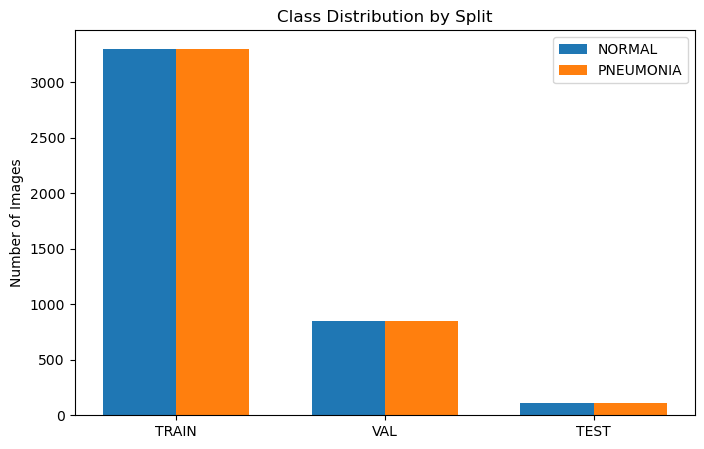

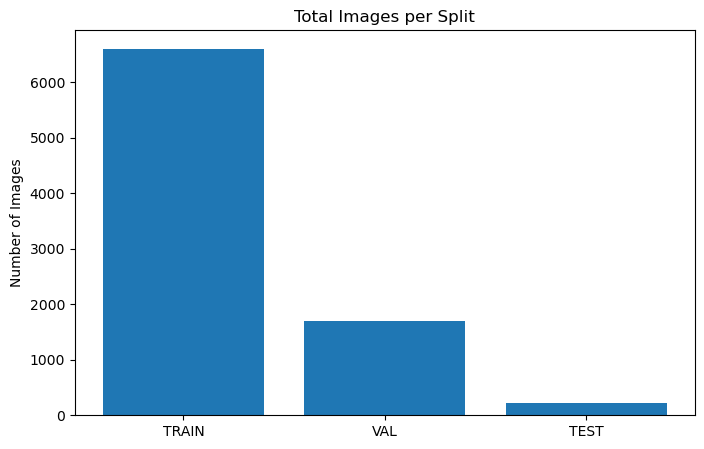

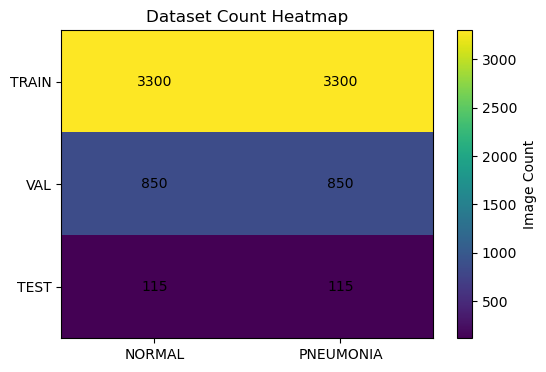

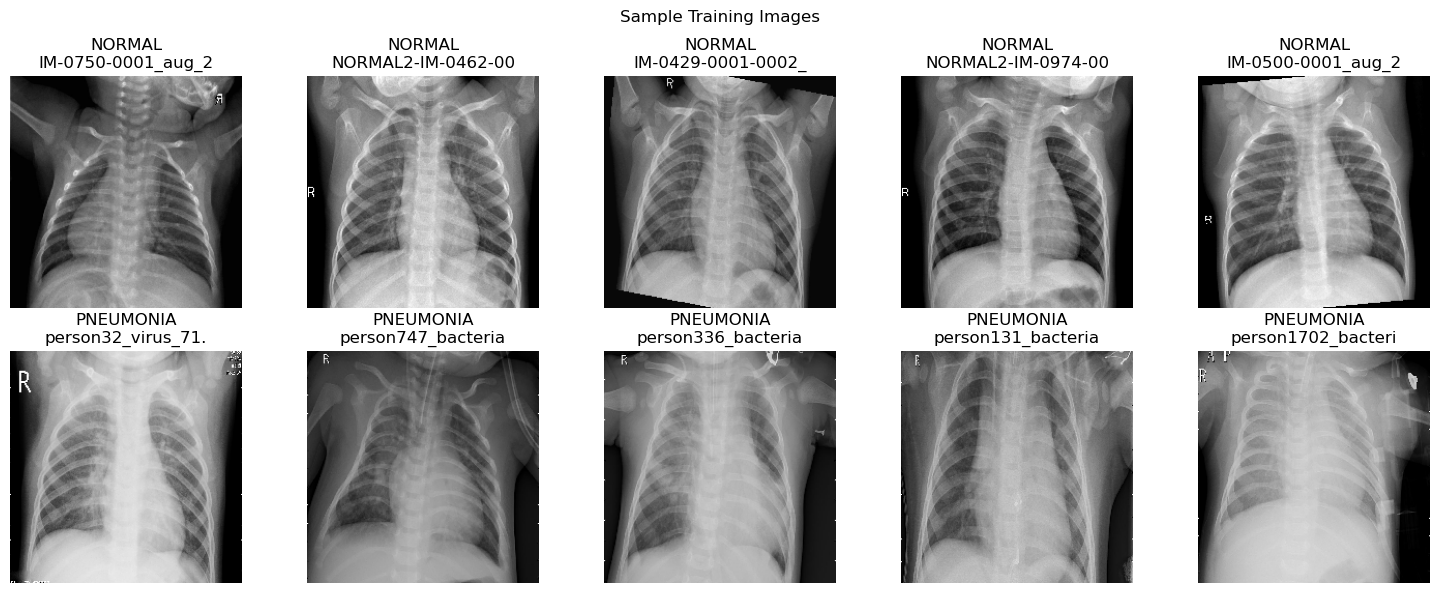

In [4]:
# =========================
# 4. DATA PREPROCESSING + VISUALIZATION
# =========================
count_table = build_dataset_count_table()
print_dataset_summary(count_table)

plot_class_distribution(count_table)
plot_split_totals(count_table)
plot_count_heatmap(count_table)
show_sample_images(samples_per_class=5, img_size=(224, 224))

## CNN model
This section uses standard image rescaling plus augmentation.

In [5]:
# =========================
# 5. CNN - DATA GENERATORS
# =========================
cnn_train_generator, cnn_val_generator, cnn_test_generator = create_cnn_generators()

print("Class indices:", cnn_train_generator.class_indices)
print("Train batches per epoch:", len(cnn_train_generator))
print("Validation batches per epoch:", len(cnn_val_generator))
print("Test batches:", len(cnn_test_generator))

Found 6600 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 230 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches per epoch: 207
Validation batches per epoch: 54
Test batches: 8


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7100 - loss: 0.5554 - val_accuracy: 0.7847 - val_loss: 0.4722
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8595 - loss: 0.3309 - val_accuracy: 0.8700 - val_loss: 0.3024
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.8747 - loss: 0.2887 - val_accuracy: 0.9076 - val_loss: 0.2298
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.8832 - loss: 0.2729 - val_accuracy: 0.9094 - val_loss: 0.2258
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.8902 - loss: 0.2619 - val_accuracy: 0.9006 - val_loss: 0.2467
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8958 - loss: 0.2510 - val_accuracy: 0.9235 - val_loss: 0.2096
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8980 - loss: 0.2430 - val_accuracy: 0.9071 - val_loss: 0.2323
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.9050 - loss: 0.2346 - val_accu

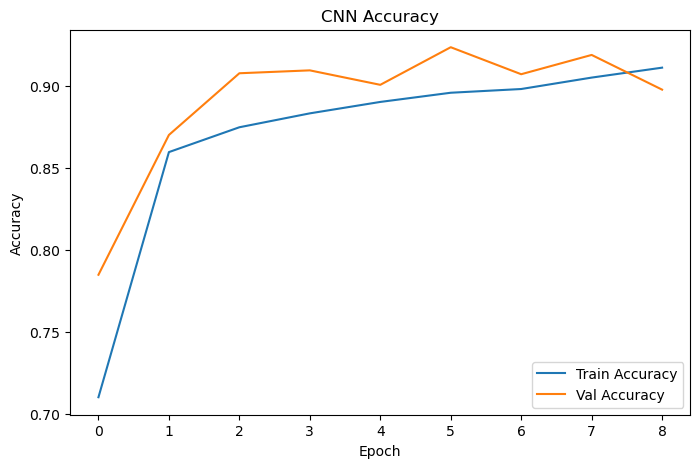

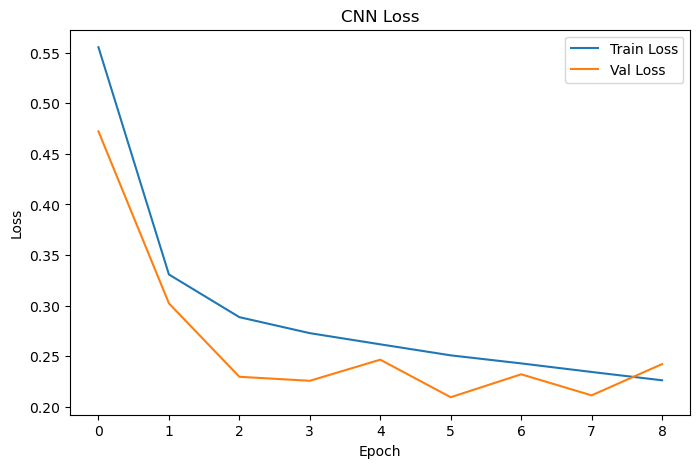

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 636ms/step - accuracy: 0.9130 - loss: 0.2439
CNN Test Loss: 0.2439
CNN Test Accuracy: 0.9130
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 501ms/step

CNN Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.88      0.91       115
   PNEUMONIA       0.89      0.95      0.92       115

    accuracy                           0.91       230
   macro avg       0.92      0.91      0.91       230
weighted avg       0.92      0.91      0.91       230

CNN Confusion Matrix:
[[101  14]
 [  6 109]]


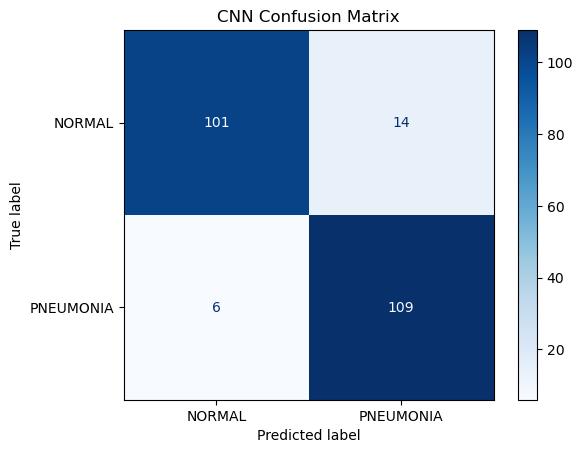

CNN model saved as pneumonia_balanced_cnn_model.h5


In [6]:
# =========================
# 6. CNN - BUILD, TRAIN, EVALUATE, SAVE
# =========================
cnn_model = Sequential([
    Input(shape=(CNN_IMG_HEIGHT, CNN_IMG_WIDTH, 3)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

cnn_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    cnn_train_generator,
    validation_data=cnn_val_generator,
    epochs=CNN_EPOCHS,
    verbose=1,
    callbacks=[cnn_early_stop]
)

plot_training_curves(cnn_history.history, title_prefix="CNN")
evaluate_model(cnn_model, cnn_test_generator, title="CNN")

cnn_model.save("pneumonia_balanced_cnn_model.h5")
print("CNN model saved as pneumonia_balanced_cnn_model.h5")

## ResNet50 model
This section uses transfer learning with ImageNet weights, then fine-tunes the last part of the network.

In [7]:
# =========================
# 7. RESNET50 - DATA GENERATORS
# =========================
resnet_train_generator, resnet_val_generator, resnet_test_generator = create_resnet_generators()

print("Class indices:", resnet_train_generator.class_indices)
print("Train batches per epoch:", len(resnet_train_generator))
print("Validation batches per epoch:", len(resnet_val_generator))
print("Test batches:", len(resnet_test_generator))

Found 6600 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 230 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches per epoch: 207
Validation batches per epoch: 54
Test batches: 8


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 54s 1us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 629s 3s/step - accuracy: 0.9300 - loss: 0.1855 - val_accuracy: 0.9506 - val_loss: 0.1375 - learning_rate: 0.0010
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 637s 3s/step - accuracy: 0.9539 - loss: 0.1257 - val_accuracy: 0.9624 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 665s 3s/step - accuracy: 0.9571 - loss: 0.1115 - val_accuracy: 0.9512 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 646s 3s/step - accuracy: 0.9635 - loss: 0.0985 - val_accuracy: 0.9153 - val_loss: 0.2332 - learning_rate: 0.0010
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 647s 3s/step - accuracy: 0.9688 - loss: 0.0905 - val_accuracy: 0.9553 - val_loss: 0.1253 - learning_rate: 2.0000e-04
Epoch 1/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 824s 4s/step - accuracy: 0.9592 - loss: 0.1276 - val_accuracy: 0.9465 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 2/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 785s 4s/step - accuracy: 0.9773 - loss: 

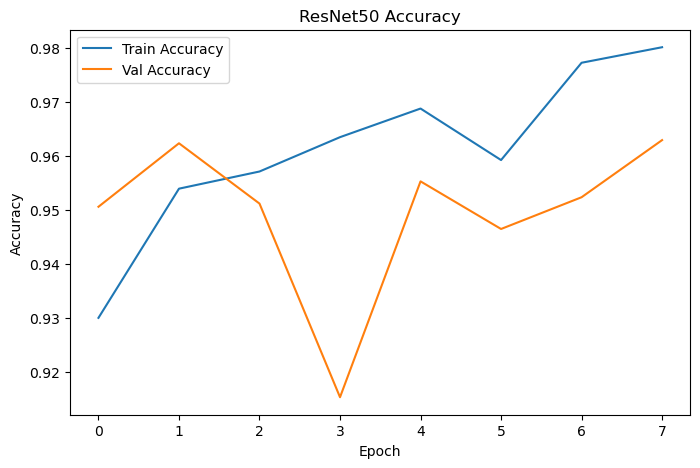

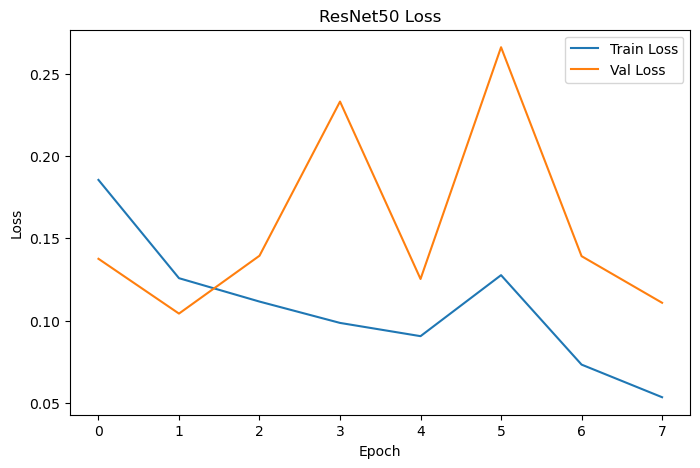

8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9565 - loss: 0.1181
ResNet50 Test Loss: 0.1181
ResNet50 Test Accuracy: 0.9565
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step

ResNet50 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.97      0.96       115
   PNEUMONIA       0.97      0.94      0.96       115

    accuracy                           0.96       230
   macro avg       0.96      0.96      0.96       230
weighted avg       0.96      0.96      0.96       230

ResNet50 Confusion Matrix:
[[112   3]
 [  7 108]]


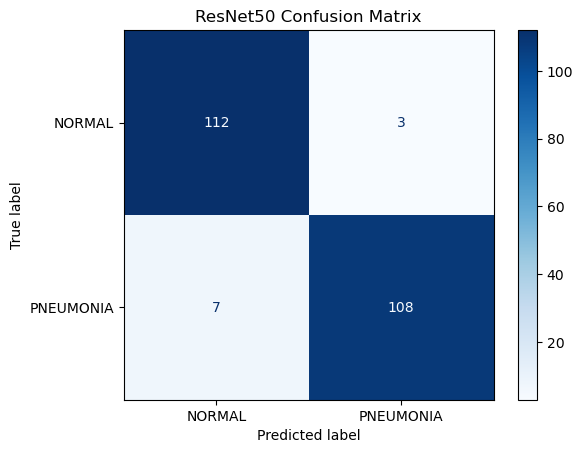

ResNet50 model saved as pneumonia_resnet50_model.h5


In [8]:
# =========================
# 8. RESNET50 - BUILD, TRAIN, EVALUATE, SAVE
# =========================
resnet_base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(TL_IMG_HEIGHT, TL_IMG_WIDTH, 3))
)

resnet_base_model.trainable = False

x = resnet_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
resnet_output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=resnet_base_model.input, outputs=resnet_output)

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

resnet_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

resnet_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

resnet_history_head = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=TL_HEAD_EPOCHS,
    verbose=1,
    callbacks=[resnet_early_stop, resnet_reduce_lr]
)

resnet_base_model.trainable = True
for layer in resnet_base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_history_finetune = resnet_model.fit(
    resnet_train_generator,
    validation_data=resnet_val_generator,
    epochs=TL_FINE_TUNE_EPOCHS,
    verbose=1,
    callbacks=[resnet_early_stop, resnet_reduce_lr]
)

resnet_combined_history = combine_histories(resnet_history_head, resnet_history_finetune)

plot_training_curves(resnet_combined_history, title_prefix="ResNet50")
evaluate_model(resnet_model, resnet_test_generator, title="ResNet50")

resnet_model.save("pneumonia_resnet50_model.h5")
print("ResNet50 model saved as pneumonia_resnet50_model.h5")

## EfficientNetB0 model
This section uses transfer learning plus a save routine that avoids the serialization issue you hit earlier.

In [9]:
# =========================
# 9. EFFICIENTNET - DATA GENERATORS
# =========================
efficientnet_train_generator, efficientnet_val_generator, efficientnet_test_generator = create_efficientnet_generators()

print("Class indices:", efficientnet_train_generator.class_indices)
print("Train batches per epoch:", len(efficientnet_train_generator))
print("Validation batches per epoch:", len(efficientnet_val_generator))
print("Test batches:", len(efficientnet_test_generator))

Found 6600 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 230 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches per epoch: 207
Validation batches per epoch: 54
Test batches: 8


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.9091 - loss: 0.2238 - val_accuracy: 0.9124 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9403 - loss: 0.1559 - val_accuracy: 0.9524 - val_loss: 0.1289 - learning_rate: 0.0010
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9473 - loss: 0.1348 - val_accuracy: 0.9447 - val_loss: 0.1450 - learning_rate: 0.0010
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.9445 - loss: 0.1349 - val_accuracy: 0.9441 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9573 - loss: 0.1115 - val_accuracy: 0.9506 - val_loss: 0.1224 - learning_rate: 2.0000e-04
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9606 - loss: 0.1012 - val_accuracy: 0.9459 - val_loss: 0.1346 - learning_rate: 2.0000e-04
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.9608 - 

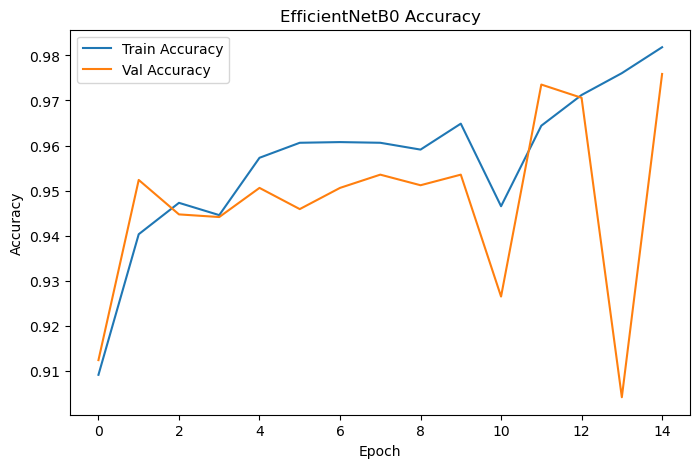

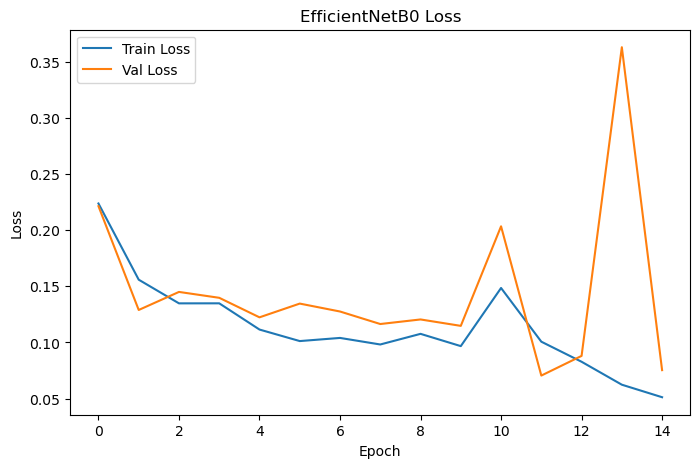

8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9696 - loss: 0.0802
EfficientNetB0 Test Loss: 0.0802
EfficientNetB0 Test Accuracy: 0.9696


8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step

EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.94      0.97       115
   PNEUMONIA       0.94      1.00      0.97       115

    accuracy                           0.97       230
   macro avg       0.97      0.97      0.97       230
weighted avg       0.97      0.97      0.97       230

EfficientNetB0 Confusion Matrix:
[[108   7]
 [  0 115]]


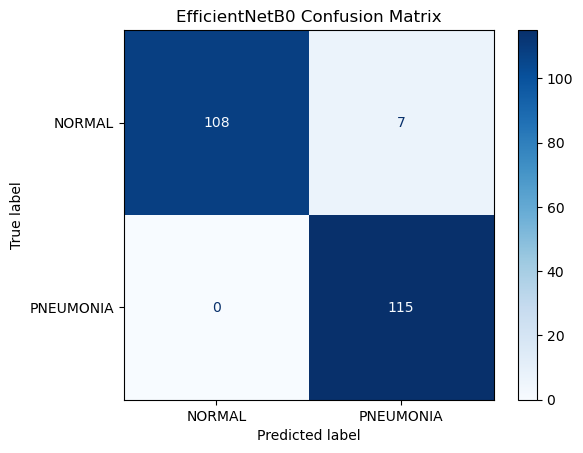

8/8 [==============================] - 8s 883ms/step - loss: 0.0834 - accuracy: 0.9783
EfficientNetB0 Test Loss: 0.0834
EfficientNetB0 Test Accuracy: 0.9783
8/8 [==============================] - 9s 883ms/step

EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.97      0.98       115
   PNEUMONIA       0.97      0.99      0.98       115

    accuracy                           0.98       230
   macro avg       0.98      0.98      0.98       230
weighted avg       0.98      0.98      0.98       230

EfficientNetB0 Confusion Matrix:
[[111   4]
 [  1 114]]


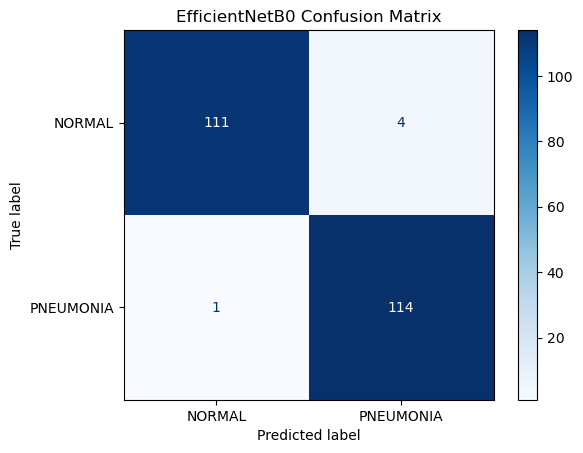

In [10]:
# =========================
# 10. EFFICIENTNET - BUILD, TRAIN, EVALUATE, SAVE
# =========================
EFFICIENTNET_MODEL_PATH = "pneumonia_efficientnet_model.keras"
EFFICIENTNET_WEIGHTS_PATH = "pneumonia_efficientnet_weights.h5"

efficientnet_base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(TL_IMG_HEIGHT, TL_IMG_WIDTH, 3))
)

efficientnet_base_model.trainable = False

x = efficientnet_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
efficientnet_output = Dense(1, activation="sigmoid")(x)

efficientnet_model = Model(
    inputs=efficientnet_base_model.input,
    outputs=efficientnet_output
)

efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

efficientnet_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

efficientnet_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# train classifier head
efficientnet_history_head = efficientnet_model.fit(
    efficientnet_train_generator,
    validation_data=efficientnet_val_generator,
    epochs=TL_HEAD_EPOCHS,
    verbose=1,
    callbacks=[efficientnet_early_stop, efficientnet_reduce_lr]
)

# fine-tune last 30 layers
efficientnet_base_model.trainable = True
for layer in efficientnet_base_model.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_history_finetune = efficientnet_model.fit(
    efficientnet_train_generator,
    validation_data=efficientnet_val_generator,
    epochs=TL_FINE_TUNE_EPOCHS,
    verbose=1,
    callbacks=[efficientnet_early_stop, efficientnet_reduce_lr]
)

# combine + plot + evaluate
efficientnet_combined_history = combine_histories(
    efficientnet_history_head,
    efficientnet_history_finetune
)

plot_training_curves(
    efficientnet_combined_history,
    title_prefix="EfficientNetB0"
)

evaluate_model(
    efficientnet_model,
    efficientnet_test_generator,
    title="EfficientNetB0"
)

In [12]:
import tensorflow as tf

SAVE_DIR = "pneumonia_efficientnet_export"
WEIGHTS_PATH = "pneumonia_efficientnet.weights.h5"

efficientnet_model.save_weights(WEIGHTS_PATH)
print("Weights saved.")

tf.saved_model.save(efficientnet_model, SAVE_DIR)
print("Full model exported.")

Weights saved.
INFO:tensorflow:Assets written to: pneumonia_efficientnet_export\assets


INFO:tensorflow:Assets written to: pneumonia_efficientnet_export\assets


Full model exported.


In [13]:
import tensorflow as tf

loaded_model = tf.saved_model.load("pneumonia_efficientnet_export")
infer = loaded_model.signatures["serving_default"]

print("Model loaded successfully.")

Model loaded successfully.


## Next step later
When you are ready, add a separate UI / manual image upload section after these model cells.